---
title: "variance and moments"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

## weird dice

Let's say I 3d print a weird die: three of the faces are 1s, and three of the faces are 6s. What is the expected value of a roll of this die?

Let's call $X2$ the random variable representing the outcome of a roll of this 3d printed die. The support of $X2$ is $\{1, 6\}$, and if the die is fair, then $P(X2=1) = P(X2=6) = 0.5$. Therefore, we can compute the expectation of $X2$ as follows:

$$
E[X2] = 1 \cdot P(X2=1) + 6 \cdot P(X2=6) = 1 \cdot 0.5 + 6 \cdot 0.5 = 3.5
$$

This is the same expected value we got for a regular die!

Just to push the point to the limit, I now 3d print a new die, whose six faces all show $3.5$. Clearly the expected value of this die is also $3.5$.

::: {.column-margin}
Let's prove this. Let's call $X3$ the random variable representing the outcome of a roll of this new die. The support of $X3$ is $\{3.5\}$, and $P(X3=3.5) = 1$. Therefore, the expectation of $X3$ is $E[X3] = \sum_{r \in \{3.5\}} r \cdot P(X3=r) = 3.5 \cdot 1 = 3.5$.
:::

I'm trying to make the point that just the mean (the expected value) of a random variable is not enough to capture all the information about the distribution of that random variable.

In [1]:
#| code-summary: "import libraries"
import numpy as np
import matplotlib.pyplot as plt

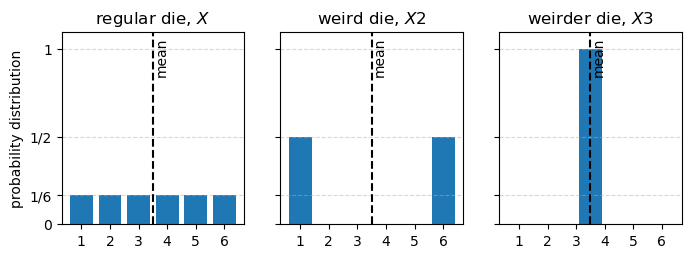

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2.5), sharey=True, sharex=True)
ax[0].bar(np.arange(1,7), [1/6]*6)
ax[1].bar([1, 6], [1/2, 1/2])
ax[2].bar([3.5], [1])
ax[0].set(xticks=np.arange(1,7),
          ylabel='probability distribution',
          ylim=(0, 1.1),
          yticks=[0, 1/6, 1/2, 1],
          yticklabels=['0', '1/6', '1/2', '1'],);
for axx in ax:
    axx.axvline(3.5, color='k', ls='--')
    axx.text(3.55, 1.07, 'mean', ha='left', va='top', rotation=90)
    axx.grid(axis='y', linestyle='--', alpha=0.5)
ax[0].set_title('regular die, $X$')
ax[1].set_title('weird die, $X2$')
ax[2].set_title('weirder die, $X3$');

## variance

Looking at the graph above, we get a sense that it is a lot more probable that the outcome of $X2$ will be further away from the mean than the outcome of $X$. The outcome of $X3$ will never deviate from the mean at all. We can capture this intuition by computing the expected squared deviation of the random variable from its mean, which is called the variance. It is squared because we don't want positive and negative deviations to cancel each other out.

For a generic random variable $X$, its variance is defined as follows:

$$
\operatorname{Var}(X) = E[(X - E[X])^2] = E[(X - \mu)^2]
$$

Now that we have the LOTUS formula under our belt, we can compute the variance of each of the three random variables we have been looking at. I'll do it in python.

In [50]:
#| code-fold: false
def compute_mean_and_variance(supp, pmf, name):
    mean = np.sum(supp * pmf)
    var = np.sum((supp - mean)**2 * pmf)
    print(f'mean of {name}: {mean:.2f}')
    print(f'variance of {name}: {var:.2f}')
    print("---")
# regular die X
compute_mean_and_variance(supp=np.arange(1, 7),
                          pmf=np.ones(6) / 6,
                          name='X')
# weird die X2
compute_mean_and_variance(supp=np.array([1, 6]),
                          pmf=np.ones(2) / 2,
                          name='X2')
# weirder die X3
compute_mean_and_variance(supp=np.array([3.5]),
                          pmf=np.ones(1),
                          name='X3')

mean of X: 3.50
variance of X: 2.92
---
mean of X2: 3.50
variance of X2: 6.25
---
mean of X3: 3.50
variance of X3: 0.00
---


The variance quantifies how much the values of a random variable are spread out around the mean. The higher the variance, the more spread out the values are. If the variance is zero, then all the values of the random variable are the same (and equal to the mean).

Note that the variance has units that are the square of the units of the random variable. If $X$ has units of cm, then $\operatorname{Var}$ has units of cm$^2$. This can make the variance hard to interpret. To get around this problem, we can take the square root of the variance, which is called the standard deviation. The standard deviation has the same units as the random variable, and it is often easier to interpret than the variance.

The standard symbol for the variance of a random variable $X$ is $\sigma^2$, and the standard symbol for the standard deviation is $\sigma$.

Let's play a little bit with the formula for the definition of variance.

\begin{align*}
\operatorname{Var} &= E[(X - E[X])^2] \\
&= E[(X - \mu)^2] \\
&= E[X^2 - 2\mu X + \mu^2] \\
&= E[X^2] - 2\mu E[X] + \mu^2 \\
&= E[X^2] - 2\mu^2 + \mu^2 \\
&= E[X^2] - \mu^2 \\
&= E[X^2] - (E[X])^2
\end{align*}

This is a useful formula for computing the variance! In a little while I'll give names for the two terms in this formula. For now, let's remember that we already calculated these two quantities in the previous chapter, when dealing with a regular die. We found that $E[X] = 3.5$ and $E[X^2] = 91/6$. Therefore, we can compute the variance of a roll of a regular die as follows:

$$
\operatorname{Var} = E[X^2] - (E[X])^2 = \frac{91}{6} - (3.5)^2 = \frac{35}{12} \approx 2.92
$$

This is the same value we got before with the Python code!

One last thing about the variance: it is always positive. This is intuitive, since the raw material for the variance is the squared deviation from the mean, and squares are always positive. We can also see this from the formula $\operatorname{Var}(X) = E[X^2] - (E[X])^2$. The term $E[X^2]$ is always greater than or equal to $(E[X])^2$, which means that $\operatorname{Var}(X)$ is always greater than or equal to zero. How do we know this last fact? That is a consequence of Jensen's inequality, which states that for any convex function $f$ and any random variable $X$, we have $E[f(X)] \geq f(E[X])$. The function $f(x) = x^2$ is convex, so we have $E[X^2] \geq (E[X])^2$, which implies that $\operatorname{Var}(X) \geq 0$.

See the graph below, I think it shows well what we are talking about. The black curve is $y=x^2$. I plotted as red circles this function evaluated at the points $x = 1$ and $x = 6$, which are the two possible outcomes of $X2$, the first weird 3d printed die. For simplicity I'll write just $X$. The red curve is the line that goes through these two red circles and its midpoint is at $(\mu, E[X^2])$, that is, the point at the average of their $x$ coordinates and the average of their $y$ coordinates. I also marked as a hollow circle the point $(\mu, (E[X])^2)$. Because the parabola $y=x^2$ is convex, the line connecting the two red circles lies above the parabola, which guarantees that $E[X^2] \geq (E[X])^2$. The variance in this case is simply the vertical distance between the two blue circles.

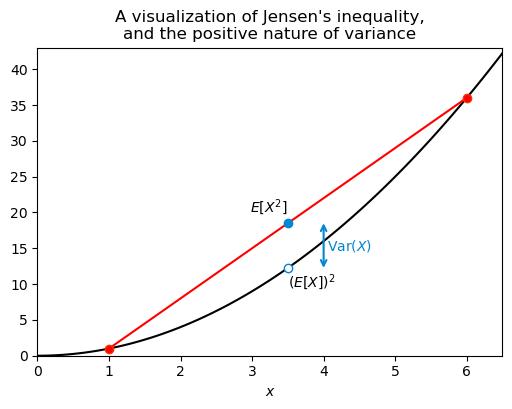

In [78]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(0, 7, 100)
x2 = np.array([1, 6])
square = lambda x: x**2
E_X2 = np.mean(square(x2))
EX_2 = square(3.5)
ax.plot(x, square(x), label='$f(x) = x^2$', color='black')
ax.plot(x2, square(x2), ls="-", color="red")
ax.plot(x2, square(x2), ls="None", marker='o', mfc="red", mec="xkcd:vermillion")
ax.plot([3.5], [EX_2], ls="None", marker='o', mfc="white", mec="xkcd:cerulean")
ax.plot([3.5], [E_X2], ls="None", marker='o', mfc="xkcd:cerulean", mec="xkcd:cerulean")
ax.text(3.5, EX_2*0.95, r'$(E[X])^2$', ha='left', va='top')
ax.text(3.5, E_X2*1.2, r'$E[X^2]$', ha='right', va='top')
ax.annotate(
    "",
    xy=(4.0, EX_2),
    xytext=(4.0, E_X2),
    arrowprops=dict(arrowstyle="<->", color="xkcd:cerulean", lw=1.5, shrinkA=0, shrinkB=0),
)
ax.text(4.05, (E_X2 + EX_2) / 2, r"$\mathrm{Var}(X)$", color="xkcd:cerulean", va="center", ha="left")
mu = 3.5
ax.set(xlim=(0, 6.5),
       ylim=(0, 43),
       xlabel='$x$',
       title="A visualization of Jensen's inequality,\nand the positive nature of variance",
       );

## moments

### raw

Previously, we saw an expression for the variance:

$$
\operatorname{Var}(X) = E[X^2] - (E[X])^2.
$$

I promised to give names to the two terms in this expression. Each of them is called a moment of the random variable $X$. In general terms, the $k$-th moment of a random variable $X$ is defined as 

$$
\mu'_k = E[X^k].
$$

For this we have that $\mu'_1 = E[X]$ is the first moment, and $\mu'_2 = E[X^2]$ is the second moment. The variance, expressed in terms of moments, is $\operatorname{Var} = \mu'_2 - (\mu'_1)^2$.

There are a few kinds of moments. What we defined above is called the raw moment.

### central

The central moments are defined as follows:

$$
\mu_k = E[(X - E[X])^k] = E[(X - \mu)^k].
$$

This is almost the same as the raw moment, the difference is that we subtract the mean from $X$ before raising it to the power of $k$. This is useful because we can say that the variance is simply the second central moment, that is, $Var(X) = \mu_2$.

### standardized

A third kind of moments are the standardized moments, which are defined as follows:

$$
\mu''_k = \frac{E[(X - E[X])^k]}{(\operatorname{Var}(X))^{k/2}} = \frac{\mu_k}{\sigma^k}.
$$

This is basically the central moment divided by the standard deviation raised to the power of $k$.

Standardized moments are useful because they give us a way to compare the shape of different distributions, regardless of their scale. For example, the standardized third moment is called the skewness, and it measures how asymmetric a distribution is. The standardized fourth moment is called the kurtosis, and it measures how heavy-tailed a distribution is.

## visualizing the moments

### mean

Changing the mean of a distribution shifts the distribution left or right, but it does not change the shape of the distribution.

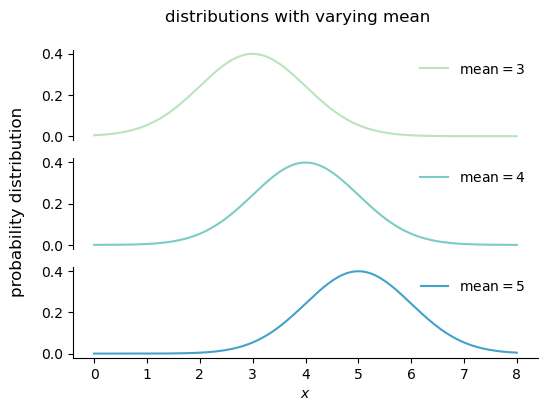

In [126]:
from scipy.stats import norm
from palettable.colorbrewer.sequential import GnBu_5
colors = GnBu_5.hex_colors

fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True, sharey=True)
mean = [3, 4, 5]
x = np.linspace(0, 8, 300)
for i, m in enumerate(mean):
    y = norm.pdf(x, loc=m, scale=1)
    ax[i].plot(x, y, color=colors[i+1], label=fr'mean$={m}$')
    ax[i].legend(frameon=False)
ax[2].set(xlabel='$x$',)
for axx in ax[:]:
    axx.spines['top'].set_visible(False)
    axx.spines['right'].set_visible(False)

ax[0].spines['bottom'].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax[1].spines['bottom'].set_visible(False)
ax[1].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

fig.supylabel("probability distribution", y=0.50, fontsize=12)
fig.suptitle("distributions with varying mean", fontsize=12);

### variance

Variance is a measure of the spread of a distribution, and it is defined as the standardized second moment:

$$
\operatorname{var}(X) = \frac{\mathbb{E}[(X - \mu)^2]}{\sigma^2}.
$$

Changing the variance of a distribution stretches or compresses the distribution along the x-axis, but it does not change the location of the center of the distribution.

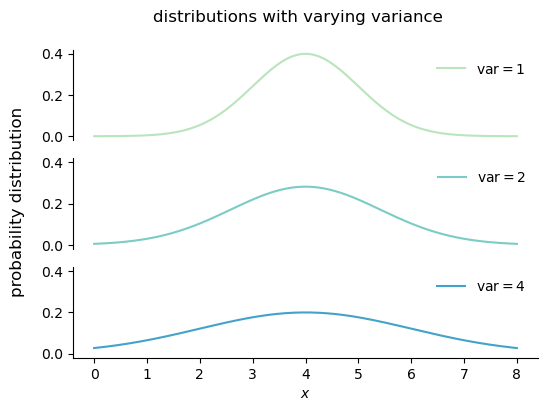

In [127]:
fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True, sharey=True)
var = [1, 2, 4]
for i, v in enumerate(var):
    y = norm.pdf(x, loc=4, scale=np.sqrt(v))
    ax[i].plot(x, y, color=colors[i+1], label=fr'var$={v}$')
    ax[i].legend(frameon=False)
ax[2].set(xlabel='$x$',)
for axx in ax[:]:
    axx.spines['top'].set_visible(False)
    axx.spines['right'].set_visible(False)

ax[0].spines['bottom'].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax[1].spines['bottom'].set_visible(False)
ax[1].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

fig.supylabel("probability distribution", y=0.50, fontsize=12)
fig.suptitle("distributions with varying variance", fontsize=12);

### skewness

Skewness is a measure of the asymmetry of a distribution, and it is defined as the standardized third moment:

$$
\operatorname{skew} = \frac{\mathbb{E}[(X - \mu)^3]}{\sigma^3}.
$$

Increasing the magnitude of the skewness of a distribution makes the distribution more asymmetric, with a longer tail on one side than on the other. Decreasing the magnitude of the skewness makes the distribution more symmetric. A distribution with zero skewness is perfectly symmetric around its mean.

A positive skewness is called right skewness, meaning that the longer tail is on the right side of the distribution. A negative skewness is called left skewness, meaning that the longer tail is on the left side of the distribution.

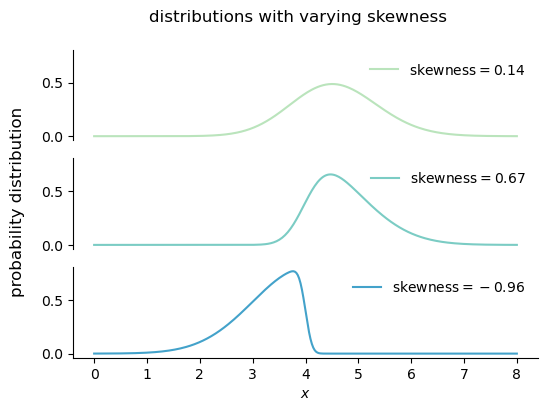

In [128]:
from scipy.stats import skewnorm

sk = [1, 3, -10]
fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True, sharey=True)
for i, s in enumerate(sk):
    y = skewnorm.pdf(x, a=s, loc=4, scale=1)
    mean, std, skew = skewnorm.stats(a=s, loc=4, scale=1, moments='mvs')
    ax[i].plot(x, y, color=colors[i+1], label=fr'skewness$={skew:.2f}$')
    ax[i].legend(frameon=False)
ax[2].set(xlabel='$x$',)
for axx in ax[:]:
    axx.spines['top'].set_visible(False)
    axx.spines['right'].set_visible(False)

ax[0].spines['bottom'].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax[1].spines['bottom'].set_visible(False)
ax[1].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

fig.supylabel("probability distribution", y=0.50, fontsize=12)
fig.suptitle("distributions with varying skewness", fontsize=12);

## kurtosis

Kurtosis is a measure of the heaviness of the tails of a distribution. The higher the kurtosis, the higher the probability of observing values far away from the mean, or outliers. Kurtosis is defined as the standardized fourth moment:

$$
\operatorname{kurt} = \frac{\mathbb{E}[(X - \mu)^4]}{\sigma^4}.
$$

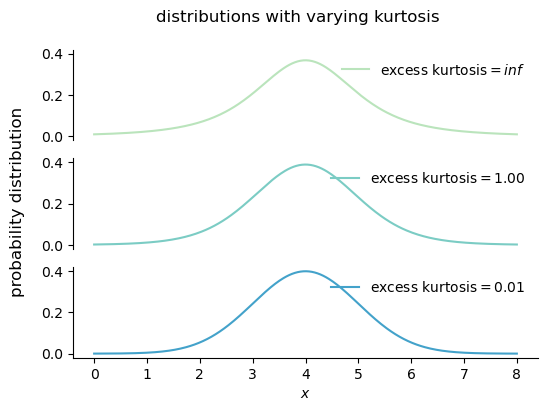

In [132]:
from scipy.stats import t

degrees_of_freedom = [3, 10, 1000]
fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True, sharey=True)
# for axx in ax:
#     axx.set_yscale('log')
for i, df in enumerate(degrees_of_freedom):
    y = t.pdf(x, df, loc=4, scale=1)
    kurt = t.stats(df, moments='k')  # excess kurtosis
    ax[i].plot(x, y, color=colors[i+1], label=fr'excess kurtosis$={kurt:.2f}$')
    ax[i].legend(frameon=False)
ax[2].set(xlabel='$x$')
for axx in ax[:]:
    axx.spines['top'].set_visible(False)
    axx.spines['right'].set_visible(False)

ax[0].spines['bottom'].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax[1].spines['bottom'].set_visible(False)
ax[1].tick_params(axis='x', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
fig.supylabel("probability distribution", y=0.50, fontsize=12)
fig.suptitle("distributions with varying kurtosis", fontsize=12);

It is quite hard to see the effect of kurtosis on the shape of a distribution, so let's plot the same curves on a log scale.

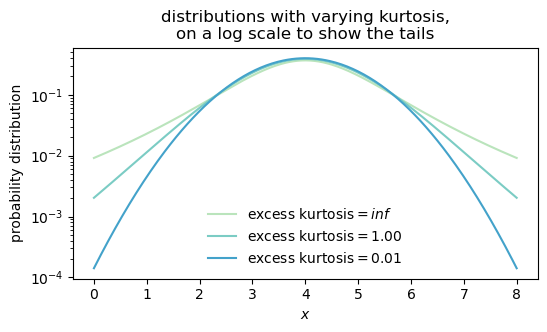

In [131]:
degrees_of_freedom = [3, 10, 1000]
fig, ax = plt.subplots(figsize=(6, 3), sharex=True, sharey=True)
ax.set_yscale('log')
for i, df in enumerate(degrees_of_freedom):
    y = t.pdf(x, df, loc=4, scale=1)
    kurt = t.stats(df, moments='k')  # excess kurtosis
    ax.plot(x, y, color=colors[i+1], label=fr'excess kurtosis$={kurt:.2f}$')
    ax.legend(frameon=False)
ax.set(xlabel='$x$',
       ylabel='probability distribution',
       title="distributions with varying kurtosis,\non a log scale to show the tails");

## Physics

The word "moment" reminds us of "moment of inertia" in Physics. Is there a connection?

Yes! Karl Pearson named moments after the moments in physics.

In Physics, a moment is a weighted sum of the form

$$
\sum_i m_i r_i^k,
$$

where $r$ is a distance from some reference point, $m$ is a mass (or force, or charge density), and the sum is over all particles. The $k$ power tells us the order of the moment:

* $k=0$: total mass,
  $$
  \sum m = M.
  $$
* $k=1$, first moment,
    $$
    \sum m r,
    $$
    gives the center of mass when divided by the total mass ($\bar{r} = \frac{\sum m r}{M}$)
* $k=2$, second moment,
    $$
    \sum m r^2,
    $$
    gives the moment of inertia. Let's call this $I=\sum m r^2$.

If we calculate the second central moment in the context of physics, we get the following:

\begin{align*}
\mu_2 &= \sum m \left(r - \bar{r}\right)^2 \\
&= \sum m r^2 + \sum m (\bar{r})^2 - 2 \sum m r \bar{r} \\
&= I + \bar{r}^2 M - 2 \bar{r} \sum m r \\
&= I + \bar{r}^2 M - 2 \bar{r} \bar{r} M \\
&= I - \bar{r}^2 M \\
&= I - I_{\text{cm}},
\end{align*}

where $I_{\text{cm}}$ is the moment of inertia of the system about an axis through the center of mass. Just by applying the definition of the second central moment, we have derived the [Parallel Axis Theorem](https://en.wikipedia.org/wiki/Parallel_axis_theorem){target="_blank"}!

This theorem states that the moment of inertia of a body about **any** axis ($I$) is equal to the moment of inertia of the body about a parallel axis through the center of mass ($I_\text{cm}$) plus the product of the mass of the body and the square of the distance between the two axes. In other words, if we know the moment of inertia of a body about an axis through its center of mass, we can calculate its moment of inertia about any other axis by adding $M d^2$, where $d$ is the distance between the two axes.